In [2]:
import os
HOME = os.getcwd()
print(HOME)

C:\Users\Merle\PycharmProjects\AIChickenCoop\ImgLabelling


https://media.roboflow.com/milk.zip

In [3]:
VIDEO_DIR_PATH = f"{HOME}/TestVids"
IMAGE_DIR_PATH = f"{HOME}/TestImgs"
FRAME_STRIDE = 60

In [4]:
import supervision as sv
from tqdm import tqdm
 
video_paths = sv.list_files_with_extensions(
    directory=VIDEO_DIR_PATH,
    extensions=["mov", "mp4"])
print(video_paths)
TEST_VIDEO_PATHS, TRAIN_VIDEO_PATHS = video_paths[:2], video_paths[2:]

for video_path in tqdm(TRAIN_VIDEO_PATHS):
    print(f"Saving images to {IMAGE_DIR_PATH}")
    video_name = video_path.stem
    image_name_pattern = video_name + "-{:05d}.png"
    print(f"Pattern: {image_name_pattern}")
    with sv.ImageSink(target_dir_path=IMAGE_DIR_PATH, image_name_pattern=image_name_pattern) as sink:
        for image in sv.get_video_frames_generator(source_path=str(video_path), stride=FRAME_STRIDE):
            sink.save_image(image=image)



[WindowsPath('C:/Users/Merle/PycharmProjects/AIChickenCoop/ImgLabelling/TestVids/SmallTest1.mp4'), WindowsPath('C:/Users/Merle/PycharmProjects/AIChickenCoop/ImgLabelling/TestVids/SmallTest2.mp4'), WindowsPath('C:/Users/Merle/PycharmProjects/AIChickenCoop/ImgLabelling/TestVids/SmallTest3.mp4'), WindowsPath('C:/Users/Merle/PycharmProjects/AIChickenCoop/ImgLabelling/TestVids/SmallTest4.mp4'), WindowsPath('C:/Users/Merle/PycharmProjects/AIChickenCoop/ImgLabelling/TestVids/SmallTest5.mp4')]


  0%|          | 0/3 [00:00<?, ?it/s]

Saving images to C:\Users\Merle\PycharmProjects\AIChickenCoop\ImgLabelling/TestImgs
Pattern: SmallTest3-{:05d}.png


 33%|███▎      | 1/3 [00:14<00:29, 14.79s/it]

Saving images to C:\Users\Merle\PycharmProjects\AIChickenCoop\ImgLabelling/TestImgs
Pattern: SmallTest4-{:05d}.png


 67%|██████▋   | 2/3 [00:30<00:15, 15.12s/it]

Saving images to C:\Users\Merle\PycharmProjects\AIChickenCoop\ImgLabelling/TestImgs
Pattern: SmallTest5-{:05d}.png


100%|██████████| 3/3 [00:44<00:00, 14.88s/it]


In [5]:
image_paths = sv.list_files_with_extensions(
    directory=IMAGE_DIR_PATH,
    extensions=["png", "jpg", "jpg"])

print('image count:', len(image_paths))

image count: 453


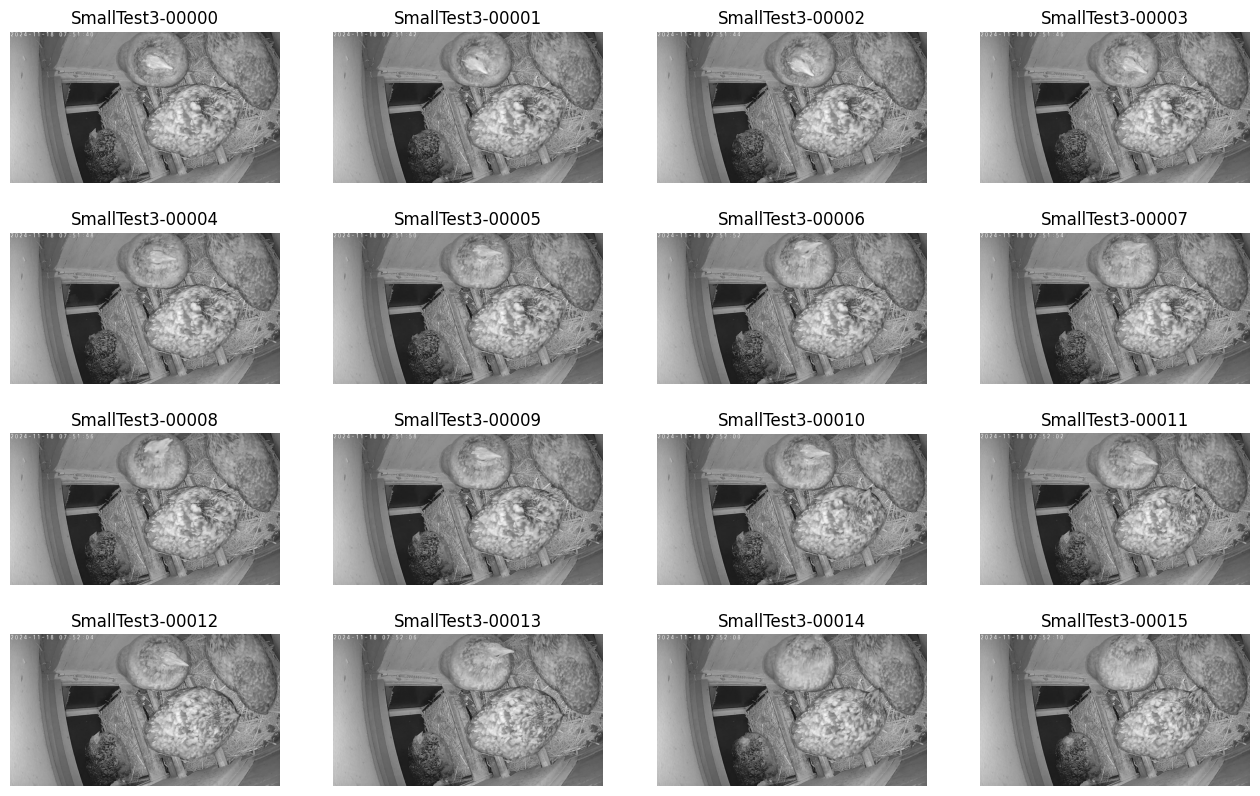

In [6]:


IMAGE_DIR_PATH = f"{HOME}/TestImgs"
SAMPLE_SIZE = 16
SAMPLE_GRID_SIZE = (4, 4)
SAMPLE_PLOT_SIZE = (16, 10)


import cv2


titles = [
    image_path.stem
    for image_path
    in image_paths[:SAMPLE_SIZE]]
images = [
    cv2.imread(str(image_path))
    for image_path
    in image_paths[:SAMPLE_SIZE]]

sv.plot_images_grid(images=images, titles=titles, grid_size=SAMPLE_GRID_SIZE, size=SAMPLE_PLOT_SIZE)



In [7]:
from autodistill.detection import CaptionOntology

ontology=CaptionOntology({
    "Chicken": "bird"
})
DATASET_DIR_PATH = f"{HOME}/TestDataset"

In [8]:
from autodistill_grounded_sam import GroundedSAM
from autodistill_grounding_dino import GroundingDINO



base_model = GroundedSAM(ontology=ontology)
dataset = base_model.label(
    input_folder=IMAGE_DIR_PATH,
    extension=".png",
    output_folder=DATASET_DIR_PATH)



Importing from timm.models.layers is deprecated, please import via timm.layers


trying to load grounding dino directly


torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)


final text_encoder_type: bert-base-uncased


You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possibl

Labeled dataset created - ready for distillation.


In [9]:


ANNOTATIONS_DIRECTORY_PATH = f"{HOME}/TestDataset/train/labels"
IMAGES_DIRECTORY_PATH = f"{HOME}/TestDataset/train/images"
DATA_YAML_PATH = f"{HOME}/TestDataset/data.yaml"



In [10]:
import supervision as sv

dataset = sv.DetectionDataset.from_yolo(
    images_directory_path=IMAGES_DIRECTORY_PATH,
    annotations_directory_path=ANNOTATIONS_DIRECTORY_PATH,
    data_yaml_path=DATA_YAML_PATH)

len(dataset)

362

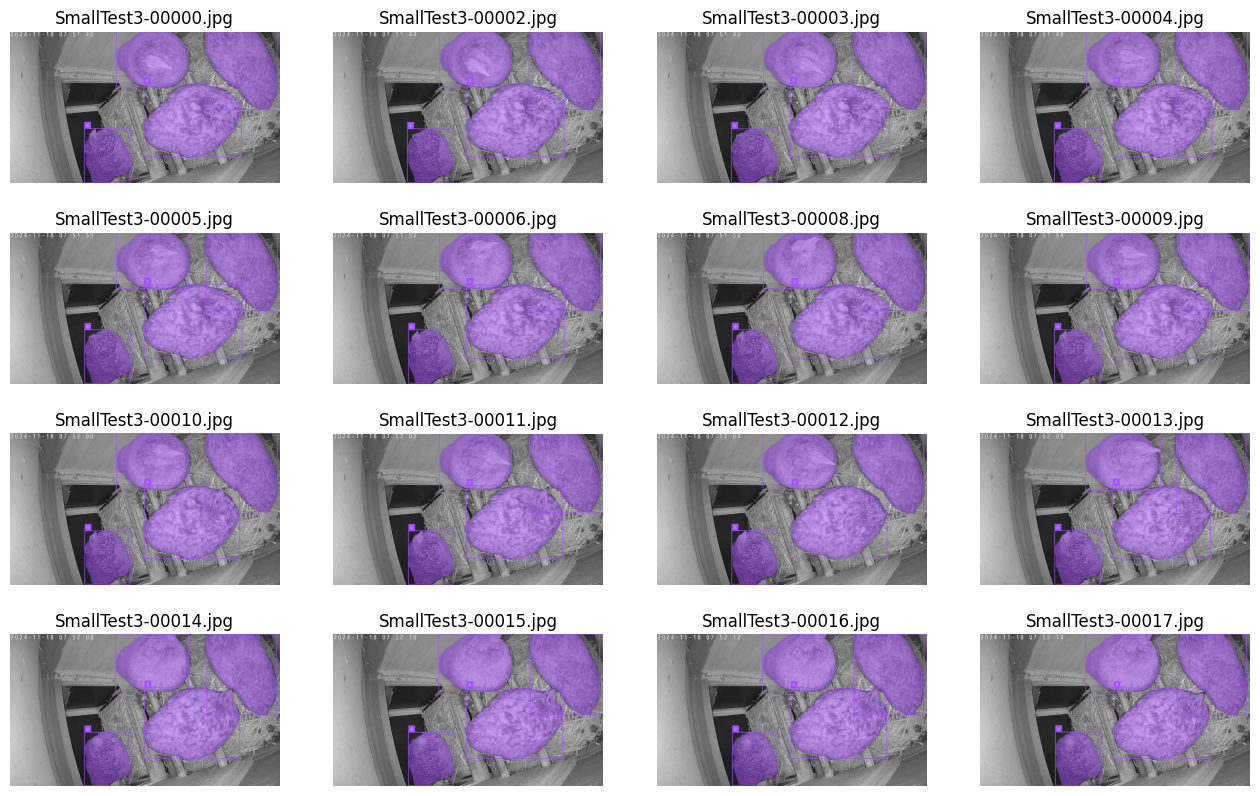

In [11]:
import supervision as sv
from pathlib import Path


mask_annotator = sv.MaskAnnotator()
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

images = []
image_names = []
for i, (image_path, image, annotation) in enumerate(dataset):
    if i == SAMPLE_SIZE:
        break
    annotated_image = image.copy()
    annotated_image = mask_annotator.annotate(
        scene=annotated_image, detections=annotation)
    annotated_image = box_annotator.annotate(
        scene=annotated_image, detections=annotation)
    annotated_image = label_annotator.annotate(
        scene=annotated_image, detections=annotation)

    image_names.append(Path(image_path).name)
    images.append(annotated_image)

sv.plot_images_grid(
    images=images,
    titles=image_names,
    grid_size=SAMPLE_GRID_SIZE,
    size=SAMPLE_PLOT_SIZE)

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL ultralytics.nn.tasks.DetectionModel was not an allowed global by default. Please use `torch.serialization.add_safe_globals([DetectionModel])` or the `torch.serialization.safe_globals([DetectionModel])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepte